#  Model Evaluation

This notebook evaluates the predictive performance of the five candidate models
on the untouched country-specific test sets created during model preparation.

The five models are:

1. Logistic Regression (LOGIT)
2. LASSO Logistic Regression
3. CART
4. Random Forest
5. BART-MIA

Evaluation is performed separately for Kenya, Tanzania, and Uganda.

The test observations were not used during model training, hyperparameter
selection, cross-validation, or preferred-model selection.

The evaluation metrics are:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- Specificity
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix

The purpose of this notebook is to assess out-of-sample predictive performance
and compare the five modelling approaches across the three countries.

## 2. IMPORT LIBRARIES

The following libraries are used for loading the fitted models, preparing the
held-out test data, calculating evaluation metrics, and generating evaluation
tables and figures.

In [20]:
# IMPORT LIBRARIES
from pathlib import Path
import matplotlib.pyplot as plt
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import subprocess
from sklearn.metrics import (

    accuracy_score,

    balanced_accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score,

    confusion_matrix,

    roc_curve,

    precision_recall_curve

)

warnings.filterwarnings("ignore")

## 3. Paths and Evaluation Configuration

The evaluation notebook uses the model outputs and test datasets produced by the
previous notebooks.


In [21]:
# PATHS AND CONFIGURATION
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "Data"
MODEL_DATA_DIR = DATA_DIR / "model"

RESULTS_DIR = PROJECT_ROOT / "results"
TRAINING_RESULTS_DIR = RESULTS_DIR / "training"
EVALUATION_RESULTS_DIR = RESULTS_DIR / "evaluation"

MODEL_OUTPUT_DIR = RESULTS_DIR / "models"

EVALUATION_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

countries = [
    "Kenya",
    "Tanzania",
    "Uganda"
]

target = "exporter"

print("Project root:")
print(PROJECT_ROOT)

print("\nCountries:")
print(countries)

print("\nTarget:")
print(target)

Project root:
/Users/eddiebest/Documents/SME_Export_Thesis

Countries:
['Kenya', 'Tanzania', 'Uganda']

Target:
exporter


## 4. Load Untouched Test Data

The country-specific test predictors and target variables are loaded from the
model-preparation outputs.

These observations are used only for final out-of-sample evaluation.

In [22]:
# LOAD TEST DATA
X_test = {}
y_test = {}

for country in countries:

    X_path = (
        MODEL_DATA_DIR /
        f"{country}_X_test.csv"
    )

    y_path = (
        MODEL_DATA_DIR /
        f"{country}_y_test.csv"
    )

    if not X_path.exists():
        raise FileNotFoundError(
            f"Missing X_test file: {X_path}"
        )

    if not y_path.exists():
        raise FileNotFoundError(
            f"Missing y_test file: {y_path}"
        )

    X_test[country] = pd.read_csv(X_path)
    y_test[country] = pd.read_csv(y_path)

    print("\n" + " " * 70)
    print(country)
   
    print(
        "X_test shape:",
        X_test[country].shape
    )

    print(
        "y_test shape:",
        y_test[country].shape
    )

    print(
        "X_test columns:",
        list(X_test[country].columns)
    )

    print(
        "y_test columns:",
        list(y_test[country].columns)
    )


                                                                      
Kenya
X_test shape: (205, 12)
y_test shape: (205, 1)
X_test columns: ['l1', 'd2', 'b7', 'b2b', 'h1', 'c22b', 'c36', 'e6', 'b3a', 'l10', 'c39', 'k30']
y_test columns: ['exporter']

                                                                      
Tanzania
X_test shape: (118, 12)
y_test shape: (118, 1)
X_test columns: ['l1', 'd2', 'b7', 'b2b', 'h1', 'c22b', 'c36', 'e6', 'b3a', 'l10', 'c39', 'k30']
y_test columns: ['exporter']

                                                                      
Uganda
X_test shape: (121, 12)
y_test shape: (121, 1)
X_test columns: ['l1', 'd2', 'b7', 'b2b', 'h1', 'c22b', 'c36', 'e6', 'b3a', 'l10', 'c39', 'k30']
y_test columns: ['exporter']


## 5. Separate Test Predictors and Target

The test predictor matrices and target vectors are separated.

The identifier column `Unnamed: 0`, if present, is not treated as a predictor.
The target variable is `exporter`.

In [23]:
# SEPARATE X AND y
X_test_eval = {}
y_test_eval = {}

for country in countries:

    X_df = X_test[country].copy()
    y_df = y_test[country].copy()

    # Remove exported dataframe index column if present.
    if "Unnamed: 0" in X_df.columns:
        X_df = X_df.drop(
            columns=["Unnamed: 0"]
        )

    if "Unnamed: 0" in y_df.columns:
        y_df = y_df.drop(
            columns=["Unnamed: 0"]
        )

    if target not in y_df.columns:
        raise ValueError(
            f"Target '{target}' not found in "
            f"{country} y_test data."
        )

    X_test_eval[country] = X_df
    y_test_eval[country] = (
        pd.to_numeric(
            y_df[target],
            errors="coerce"
        )
    )

    print(
        f"{country}: "
        f"X={X_test_eval[country].shape}, "
        f"y={y_test_eval[country].shape}"
    )

Kenya: X=(205, 12), y=(205,)
Tanzania: X=(118, 12), y=(118,)
Uganda: X=(121, 12), y=(121,)


## 6. Test-Set Structure Validation

Before evaluating the models, the held-out test sets are checked for:

- non-empty observations;
- the expected target variable;
- binary target values;
- matching numbers of observations between X and y;
- consistent predictor structure across countries.

In [24]:
# TEST STRUCTURE VALIDATION
for country in countries:

    X_df = X_test_eval[country]
    y_series = y_test_eval[country]

    print("\n" + " " * 70)
    print(country)
   

    assert len(X_df) > 0
    assert len(y_series) > 0

    assert len(X_df) == len(y_series)

    assert y_series.notna().all()

    target_values = set(
        y_series.unique()
    )

    assert target_values.issubset({0, 1}), (
        f"Invalid target values in {country}: "
        f"{target_values}"
    )

    print("Observations:", len(X_df))
    print("Predictors:", X_df.shape[1])
    print("Target values:", sorted(target_values))
    print("Structure validation: PASSED")


                                                                      
Kenya
Observations: 205
Predictors: 12
Target values: [np.int64(0), np.int64(1)]
Structure validation: PASSED

                                                                      
Tanzania
Observations: 118
Predictors: 12
Target values: [np.int64(0), np.int64(1)]
Structure validation: PASSED

                                                                      
Uganda
Observations: 121
Predictors: 12
Target values: [np.int64(0), np.int64(1)]
Structure validation: PASSED


## 7. Load Preferred Model Information

The preferred models selected during model development are loaded from
`04_model_training.ipynb`.

This information is used to identify the best-performing candidate model for
each country before final interpretation of the test-set results.

In [25]:

#  LOAD PREFERRED MODELS


preferred_path = (
    TRAINING_RESULTS_DIR /
    "preferred_models_by_country.csv"
)

if not preferred_path.exists():
    raise FileNotFoundError(
        f"Preferred-model file not found: "
        f"{preferred_path}"
    )

preferred_models = pd.read_csv(
    preferred_path
)

display(preferred_models)

assert set(
    preferred_models["Country"]
) == set(countries)

print(
    "\nPreferred-model information loaded successfully."
)

,Country,Model,Best_CV_ROC_AUC,Best_Parameters
0,Kenya,Random Forest,0.957440,"{'model__max_depth': 20, 'model__max_features'..."
1,Tanzania,Random Forest,0.973293,"{'model__max_depth': None, 'model__max_feature..."
2,Uganda,Random Forest,0.990479,"{'model__max_depth': 20, 'model__max_features'..."



Preferred-model information loaded successfully.


## 8. Load Fitted Scikit-Learn Models

The fitted Logistic Regression, LASSO Logistic Regression, CART, and Random
Forest models saved during model training are loaded.



In [26]:
#LOAD FITTED TRADITIONAL MODELS
traditional_models = {
    country: {}
    for country in countries
}

traditional_model_names = [
    "Logistic Regression",
    "LASSO Logistic Regression",
    "CART",
    "Random Forest"
]

for country in countries:

    for model_name in traditional_model_names:

        model_filename = (
            f"{country}_"
            f"{model_name.replace(' ', '_')}"
            f".joblib"
        )

        model_path = (
            MODEL_OUTPUT_DIR /
            model_filename
        )

        if not model_path.exists():

            raise FileNotFoundError(
                f"Fitted model not found:\n"
                f"{model_path}\n\n"
                f"Check Cell 20 of "
                f"04_model_training.ipynb."
            )

        traditional_models[country][model_name] = (
            joblib.load(model_path)
        )

        print(
            f"Loaded: {country} — {model_name}"
        )

print(
    "\nTraditional fitted models loaded successfully."
)

Loaded: Kenya — Logistic Regression
Loaded: Kenya — LASSO Logistic Regression
Loaded: Kenya — CART
Loaded: Kenya — Random Forest
Loaded: Tanzania — Logistic Regression
Loaded: Tanzania — LASSO Logistic Regression
Loaded: Tanzania — CART
Loaded: Tanzania — Random Forest
Loaded: Uganda — Logistic Regression
Loaded: Uganda — LASSO Logistic Regression
Loaded: Uganda — CART
Loaded: Uganda — Random Forest

Traditional fitted models loaded successfully.


## 9. Generate Out-of-Sample Predictions

The fitted models are applied to the untouched country-specific test sets.

For each model, two outputs are obtained:

- predicted class (`0` or `1`);
- predicted probability of exporter status.

The predicted probabilities are required for threshold-independent metrics such as
ROC-AUC and PR-AUC.



In [27]:

#  GENERATE TEST-SET PREDICTIONS


predictions = {
    country: {}
    for country in countries
}

probabilities = {
    country: {}
    for country in countries
}

for country in countries:

    Xte = X_test_eval[country]

    print("\n" + " " * 70)
    print(country)
   

    for model_name in traditional_model_names:

        model = traditional_models[country][model_name]

       
        # Predicted class
       

        y_pred = model.predict(Xte)

      
        # Predicted probability
       

        if hasattr(model, "predict_proba"):

            y_prob = model.predict_proba(Xte)[:, 1]

        elif hasattr(model, "decision_function"):

            # Fallback for models without predict_proba
            decision = model.decision_function(Xte)

            y_prob = (
                1 /
                (
                    1 +
                    np.exp(-decision)
                )
            )

        else:

            raise AttributeError(
                f"{model_name} does not provide "
                f"predict_proba or decision_function."
            )

        predictions[country][model_name] = (
            np.asarray(y_pred).astype(int)
        )

        probabilities[country][model_name] = (
            np.asarray(y_prob)
        )

        print(
            f"{model_name}: "
            f"{len(y_pred)} predictions generated"
        )

print("\nTest-set prediction generation: PASSED")


                                                                      
Kenya
Logistic Regression: 205 predictions generated
LASSO Logistic Regression: 205 predictions generated
CART: 205 predictions generated
Random Forest: 205 predictions generated

                                                                      
Tanzania
Logistic Regression: 118 predictions generated
LASSO Logistic Regression: 118 predictions generated
CART: 118 predictions generated
Random Forest: 118 predictions generated

                                                                      
Uganda
Logistic Regression: 121 predictions generated
LASSO Logistic Regression: 121 predictions generated
CART: 121 predictions generated
Random Forest: 121 predictions generated

Test-set prediction generation: PASSED


## 10. Prediction Validation

The generated predictions are checked to ensure that:

- the number of predictions equals the number of test observations;
- predicted classes are binary;
- predicted probabilities are finite;
- predicted probabilities lie between 0 and 1.

These checks ensure that the subsequent evaluation metrics are calculated from
valid out-of-sample predictions.

In [28]:
# VALIDATE PREDICTIONS
for country in countries:

    n_test = len(
        y_test_eval[country]
    )

    for model_name in traditional_model_names:

        y_pred = predictions[country][model_name]
        y_prob = probabilities[country][model_name]

        assert len(y_pred) == n_test
        assert len(y_prob) == n_test

        assert set(
            np.unique(y_pred)
        ).issubset({0, 1})

        assert np.isfinite(y_prob).all()

        assert (
            (y_prob >= 0) &
            (y_prob <= 1)
        ).all()

print("Prediction length validation: PASSED")
print("Prediction class validation: PASSED")
print("Probability validation: PASSED")

Prediction length validation: PASSED
Prediction class validation: PASSED
Probability validation: PASSED


## 11. Evaluation Metrics

The following out-of-sample metrics are calculated:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- Specificity
- F1-score
- ROC-AUC
- PR-AUC

Specificity is calculated from the confusion matrix as the proportion of
non-exporters correctly identified as non-exporters.

ROC-AUC measures discrimination across classification thresholds, while PR-AUC
summarises the precision-recall relationship and is particularly informative
when the positive class is relatively uncommon.

In [29]:
# EVALUATION METRICS FUNCTION


def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):
    """
    Calculate out-of-sample binary classification metrics.
    """

    
    # Confusion matrix
   

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

   
    # Specificity
    

    if (tn + fp) > 0:
        specificity = tn / (tn + fp)
    else:
        specificity = np.nan

    
    # Standard metrics
    

    metrics = {

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Specificity": specificity,

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),

        "PR_AUC": average_precision_score(
            y_true,
            y_prob
        )
    }

    return metrics

## 12. Out-of-Sample Evaluation - Four Traditional Models

Each fitted model is evaluated on its corresponding untouched test set.

The resulting metrics represent genuine out-of-sample predictive performance.



In [30]:
# EVALUATE FOUR TRADITIONAL MODELS
evaluation_results = []

confusion_matrices = {}

for country in countries:

    confusion_matrices[country] = {}

    y_true = y_test_eval[country]

    for model_name in traditional_model_names:

        y_pred = predictions[country][model_name]
        y_prob = probabilities[country][model_name]

        metrics = calculate_metrics(
            y_true=y_true,
            y_pred=y_pred,
            y_prob=y_prob
        )

        row = {
            "Country": country,
            "Model": model_name,
            **metrics
        }

        evaluation_results.append(row)

        confusion_matrices[country][model_name] = (
            confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            )
        )

evaluation_results_df = pd.DataFrame(
    evaluation_results
)

display(
    evaluation_results_df
)

,Country,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,Kenya,Logistic Regression,0.765854,0.704964,0.392857,0.611111,0.798817,0.478261,0.767751,0.550508
1,Kenya,LASSO Logistic Regression,0.765854,0.704964,0.392857,0.611111,0.798817,0.478261,0.767587,0.550345
2,Kenya,CART,0.795122,0.700855,0.434783,0.555556,0.846154,0.487805,0.792735,0.437131
3,Kenya,Random Forest,0.829268,0.699704,0.514286,0.500000,0.899408,0.507042,0.848948,0.557891
4,Tanzania,Logistic Regression,0.711864,0.635993,0.257143,0.529412,0.742574,0.346154,0.712289,0.291434
5,Tanzania,LASSO Logistic Regression,0.669492,0.635702,0.238095,0.588235,0.683168,0.338983,0.692487,0.274068
6,Tanzania,CART,0.788136,0.631625,0.318182,0.411765,0.851485,0.358974,0.645312,0.278135
7,Tanzania,Random Forest,0.855932,0.622306,0.500000,0.294118,0.950495,0.370370,0.747234,0.426504
8,Uganda,Logistic Regression,0.768595,0.667379,0.241379,0.538462,0.796296,0.333333,0.759259,0.426144
9,Uganda,LASSO Logistic Regression,0.768595,0.667379,0.241379,0.538462,0.796296,0.333333,0.759259,0.426144


## 13. BART-MIA Test-Set Predictions

The fitted BART-MIA models saved during model training are applied to the
corresponding untouched test sets.

BART-MIA predictions are generated using the model's native missing-data
handling.

No imputation is introduced specifically for the BART-MIA evaluation.

The resulting posterior predictive probabilities are used to calculate the
same evaluation metrics applied to the four traditional models.

In [31]:

# BART-MIA TEST PREDICTIONS


bart_predictions = {}
bart_probabilities = {}

bart_model_paths = {}

for country in countries:

    model_path = (
        MODEL_OUTPUT_DIR /
        f"BART_MIA_{country}.rds"
    )

    if not model_path.exists():
        raise FileNotFoundError(
            f"BART-MIA model not found for {country}:\n"
            f"{model_path}"
        )

    bart_model_paths[country] = model_path

    print(
        f"{country}: "
        f"BART-MIA model found → {model_path}"
    )

print("\nAll BART-MIA model files located successfully.")

Kenya: BART-MIA model found → /Users/eddiebest/Documents/SME_Export_Thesis/results/models/BART_MIA_Kenya.rds
Tanzania: BART-MIA model found → /Users/eddiebest/Documents/SME_Export_Thesis/results/models/BART_MIA_Tanzania.rds
Uganda: BART-MIA model found → /Users/eddiebest/Documents/SME_Export_Thesis/results/models/BART_MIA_Uganda.rds

All BART-MIA model files located successfully.


## 14. Generate BART-MIA Out-of-Sample Predictions

The fitted BART-MIA models are loaded in R and used to generate posterior
predictive probabilities for the untouched test observations.

For binary classification, the posterior probability of class `1` is used as
the exporter probability.

A classification threshold of 0.5 is used to generate predicted classes for
threshold-dependent metrics.

The predicted probabilities are retained for ROC-AUC and PR-AUC calculations.

In [32]:

# BART-MIA TEST PREDICTIONS
R_EXECUTABLE = shutil.which("R")

if R_EXECUTABLE is None:

    raise RuntimeError(

        "R executable was not found. "

        "Make sure R is installed and available in PATH."

    )

print(f"R executable: {R_EXECUTABLE}")
required_objects = [
    "countries",
    "X_test_eval",
    "y_test_eval",
    "bart_model_paths",
    "EVALUATION_RESULTS_DIR"
]

for object_name in required_objects:
    if object_name not in globals():
        raise RuntimeError(
            f"Required object `{object_name}` is not available. "
            "Run the earlier evaluation cells first."
        )

bart_eval_dir = (
    EVALUATION_RESULTS_DIR /
    "bart_mia"
)

bart_eval_dir.mkdir(
    parents=True,
    exist_ok=True
)

bart_predictions = {}
bart_probabilities = {}

for country in countries:

    print("\n")
    print(f"BART-MIA — {country}")

    X_test_country = (
        X_test_eval[country]
        .copy()
    )

    y_test_country = (
        y_test_eval[country]
        .copy()
    )

    print(
        f"Test observations: {len(X_test_country)}"
    )

    print(
        f"Test predictors:   {X_test_country.shape[1]}"
    )

    if len(X_test_country) != len(y_test_country):
        raise ValueError(
            f"{country}: X_test and y_test have different lengths.\n"
            f"X_test = {len(X_test_country)}\n"
            f"y_test = {len(y_test_country)}"
        )

    X_path = (
        bart_eval_dir /
        f"{country}_X_test.csv"
    )

    y_path = (
        bart_eval_dir /
        f"{country}_y_test.csv"
    )

    probability_path = (
        bart_eval_dir /
        f"{country}_probabilities.csv"
    )

    X_test_country.to_csv(
        X_path,
        index=False
    )

    pd.DataFrame({
        "exporter": y_test_country.astype(int)
    }).to_csv(
        y_path,
        index=False
    )

    model_path = Path(
        bart_model_paths[country]
    )

    if not model_path.exists():
        raise FileNotFoundError(
            f"BART-MIA model not found for {country}:\n"
            f"{model_path}"
        )

    print(
        f"BART model:\n{model_path}"
    )

    r_script = f'''
options(
    java.parameters = c(
        "-Xmx20g",
        "--add-modules=jdk.incubator.vector",
        "-XX:+UseZGC"
    )
)

library(bartMachine)

model <- readRDS(
    "{model_path}"
)

X_test <- read.csv(
    "{X_path}",
    check.names = FALSE
)

cat(
    "BART-MIA TEST PREDICTION — {country}\\n"
)

cat(
    "Test observations:",
    nrow(X_test),
    "\\n"
)

cat(
    "Test predictors:",
    ncol(X_test),
    "\\n"
)

probability <- predict(
    model,
    new_data = X_test,
    type = "prob"
)

probability <- as.numeric(
    probability
)

cat(
    "Prediction length:",
    length(probability),
    "\\n"
)

cat(
    "Expected length:",
    nrow(X_test),
    "\\n"
)

if (
    length(probability) != nrow(X_test)
) {{
    stop(
        paste0(
            "Prediction length mismatch. Expected ",
            nrow(X_test),
            " but received ",
            length(probability)
        )
    )
}}

if (
    any(is.na(probability))
) {{
    stop(
        "BART-MIA returned NA probabilities."
    )
}}

if (
    any(
        probability < 0 |
        probability > 1
    )
) {{
    stop(
        "BART-MIA returned probabilities outside [0, 1]."
    )
}}

write.csv(
    data.frame(
        probability = probability
    ),
    "{probability_path}",
    row.names = FALSE
)

cat(
    "BART-MIA prediction completed: {country}\\n"
)
'''

    r_script_path = (
        bart_eval_dir /
        f"evaluate_{country}.R"
    )

    r_script_path.write_text(
        r_script,
        encoding="utf-8"
    )

    print(
        f"R script created:\n{r_script_path}"
    )

    print(

        "Running BART-MIA in R..."

    )

    result = subprocess.run(

        [

            R_EXECUTABLE,

            "--vanilla",

            "--no-save",

            "--no-restore",

            "-f",

            str(r_script_path)

        ],

        capture_output=True,

        text=True

    )


    if result.stdout:

        print(

            "\nR output:"

        )

        print(

            result.stdout

        )


    if result.stderr:

        stderr_clean = result.stderr.strip()

        harmless_messages = [
            "WARNING: Using incubator modules: jdk.incubator.vector",
            "Welcome to bartMachine v1.4.2!"
        ]

        unexpected_lines = []

        for line in stderr_clean.splitlines():

            if not any(
                message in line
                for message in harmless_messages
            ):
                unexpected_lines.append(line)

        if unexpected_lines:
            print(
                "\nR messages/errors:"
            )
            print(
                "\n".join(unexpected_lines)
            )

    if result.returncode != 0:
        raise RuntimeError(
            f"BART-MIA prediction failed for {country}.\n\n"
            f"R output:\n{result.stdout}\n\n"
            f"R messages/errors:\n{result.stderr}"
        )

    if not probability_path.exists():
        raise FileNotFoundError(
            f"BART-MIA probability file was not created:\n"
            f"{probability_path}"
        )

    prob_df = pd.read_csv(
        probability_path
    )

    if "probability" not in prob_df.columns:
        raise KeyError(
            f"`probability` column missing from:\n"
            f"{probability_path}"
        )

    y_prob = (
        prob_df["probability"]
        .to_numpy(dtype=float)
    )

    expected_length = len(
        y_test_country
    )

    actual_length = len(
        y_prob
    )

    print(
        f"Expected predictions: {expected_length}"
    )

    print(
        f"Actual predictions:   {actual_length}"
    )

    if actual_length != expected_length:
        raise ValueError(
            f"{country}: BART-MIA prediction length mismatch.\n"
            f"Expected: {expected_length}\n"
            f"Actual: {actual_length}"
        )

    if np.isnan(y_prob).any():
        raise ValueError(
            f"{country}: NaN probabilities detected."
        )

    if (
        (y_prob < 0).any()
        or
        (y_prob > 1).any()
    ):
        raise ValueError(
            f"{country}: invalid probabilities detected."
        )

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    bart_probabilities[country] = y_prob
    bart_predictions[country] = y_pred

    print(
        f"Probability predictions: {len(y_prob)}"
    )

    print(
        f"Predicted exporters: {int(y_pred.sum())}"
    )

    print(
        f"Observed exporters: {int(y_test_country.sum())}"
    )

    print(
        f"Minimum probability: {y_prob.min():.6f}"
    )

    print(
        f"Maximum probability: {y_prob.max():.6f}"
    )

    print(
        f"Mean probability: {y_prob.mean():.6f}"
    )

    print(
        f"{country} BART-MIA test predictions validated."
    )

assert (
    set(bart_predictions.keys())
    ==
    set(countries)
)

assert (
    set(bart_probabilities.keys())
    ==
    set(countries)
)

for country in countries:

    assert (
        len(bart_predictions[country])
        ==
        len(y_test_eval[country])
    )

    assert (
        len(bart_probabilities[country])
        ==
        len(y_test_eval[country])
    )

print("\nBART-MIA TEST PREDICTIONS — FINAL VALIDATION")

for country in countries:
    print(f" {country}")

print(
    "\nBART-MIA test prediction generation: PASSED"
)
assert (

    set(bart_predictions.keys())

    ==

    set(countries)

)

assert (

    set(bart_probabilities.keys())

    ==

    set(countries)

)

for country in countries:

    assert (

        len(bart_predictions[country])

        ==

        len(y_test_eval[country])

    )

    assert (

        len(bart_probabilities[country])

        ==

        len(y_test_eval[country])

    )

print(

    "\n"

    

)

print(

    "BART-MIA TEST PREDICTIONS — FINAL VALIDATION"

)


for country in countries:

    print(

        f" {country}"

    )

print(

    "\nBART-MIA test prediction generation: PASSED"

)

R executable: /usr/local/bin/R


BART-MIA — Kenya
Test observations: 205
Test predictors:   12
BART model:
/Users/eddiebest/Documents/SME_Export_Thesis/results/models/BART_MIA_Kenya.rds
R script created:
/Users/eddiebest/Documents/SME_Export_Thesis/results/evaluation/bart_mia/evaluate_Kenya.R
Running BART-MIA in R...

R output:

R version 4.6.1 (2026-06-24) -- "Happy Hop"
Copyright (C) 2026 The R Foundation for Statistical Computing
Platform: aarch64-apple-darwin23

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> 
> options(
+     java.parameters = c(
+         "

## 15. Validate BART-MIA Predictions

The BART-MIA predictions are checked for consistency with the corresponding
test samples.

The validation confirms that:

- the number of predictions equals the test sample size;
- predicted classes are binary;
- probabilities are finite;
- probabilities lie between 0 and 1.

In [33]:

# VALIDATE BART-MIA PREDICTIONS


for country in countries:

    y_true = y_test_eval[country]

    y_pred = bart_predictions[country]
    y_prob = bart_probabilities[country]

    assert len(y_pred) == len(y_true), (
        f"{country}: BART-MIA prediction length mismatch."
    )

    assert len(y_prob) == len(y_true), (
        f"{country}: BART-MIA probability length mismatch."
    )

    assert set(
        np.unique(y_pred)
    ).issubset({0, 1}), (
        f"{country}: invalid BART-MIA predicted classes."
    )

    assert np.isfinite(y_prob).all(), (
        f"{country}: non-finite BART-MIA probabilities."
    )

    assert (
        (y_prob >= 0) &
        (y_prob <= 1)
    ).all(), (
        f"{country}: BART-MIA probabilities outside [0,1]."
    )

    print(
        f"{country}: BART-MIA prediction validation — PASSED"
    )

print("\nBART-MIA prediction validation: PASSED")

Kenya: BART-MIA prediction validation — PASSED
Tanzania: BART-MIA prediction validation — PASSED
Uganda: BART-MIA prediction validation — PASSED

BART-MIA prediction validation: PASSED


## 16. BART-MIA Out-of-Sample Evaluation

BART-MIA is evaluated using exactly the same performance metrics as the other
candidate models.

This allows a direct comparison between the five modelling approaches.The evaluation uses only the untouched test observations.

In [34]:

# CELL  EVALUATE BART-MIA


bart_evaluation_results = []

for country in countries:

    y_true = y_test_eval[country]

    y_pred = bart_predictions[country]
    y_prob = bart_probabilities[country]

    metrics = calculate_metrics(
        y_true=y_true,
        y_pred=y_pred,
        y_prob=y_prob
    )

    row = {
        "Country": country,
        "Model": "BART-MIA",
        **metrics
    }

    bart_evaluation_results.append(row)

bart_evaluation_df = pd.DataFrame(
    bart_evaluation_results
)

display(
    bart_evaluation_df
)

print("\nBART-MIA evaluation completed.")

,Country,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,Kenya,BART-MIA,0.863415,0.643902,0.785714,0.305556,0.982249,0.440000,0.852564,0.626582
1,Tanzania,BART-MIA,0.847458,0.519511,0.333333,0.058824,0.980198,0.100000,0.774607,0.432415
2,Uganda,BART-MIA,0.892562,0.601496,0.500000,0.230769,0.972222,0.315789,0.773504,0.408554



BART-MIA evaluation completed.


## 17. Combined Out-of-Sample Evaluation Results

The evaluation results for the four traditional models and BART-MIA are combined
into one country-level comparison table.

There should be:

- 5 models for Kenya;
- 5 models for Tanzania;
- 5 models for Uganda;

giving 15 model-country evaluation results in total.

These are final out-of-sample test-set results.

In [35]:
# CELL COMBINE ALL FIVE MODELS


all_evaluation_results = pd.concat(
    [
        evaluation_results_df,
        bart_evaluation_df
    ],
    ignore_index=True
)

model_order = [
    "Logistic Regression",
    "LASSO Logistic Regression",
    "CART",
    "Random Forest",
    "BART-MIA"
]

all_evaluation_results["Model"] = pd.Categorical(
    all_evaluation_results["Model"],
    categories=model_order,
    ordered=True
)

all_evaluation_results = (
    all_evaluation_results
    .sort_values(
        ["Country", "Model"]
    )
    .reset_index(drop=True)
)

display(
    all_evaluation_results
)

assert len(all_evaluation_results) == 15

assert (
    all_evaluation_results
    .groupby("Country", observed=False)["Model"]
    .nunique()
    .eq(5)
    .all()
)

print("\nFive-model evaluation table: PASSED")

,Country,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,Kenya,Logistic Regression,0.765854,0.704964,0.392857,0.611111,0.798817,0.478261,0.767751,0.550508
1,Kenya,LASSO Logistic Regression,0.765854,0.704964,0.392857,0.611111,0.798817,0.478261,0.767587,0.550345
2,Kenya,CART,0.795122,0.700855,0.434783,0.555556,0.846154,0.487805,0.792735,0.437131
3,Kenya,Random Forest,0.829268,0.699704,0.514286,0.500000,0.899408,0.507042,0.848948,0.557891
4,Kenya,BART-MIA,0.863415,0.643902,0.785714,0.305556,0.982249,0.440000,0.852564,0.626582
5,Tanzania,Logistic Regression,0.711864,0.635993,0.257143,0.529412,0.742574,0.346154,0.712289,0.291434
6,Tanzania,LASSO Logistic Regression,0.669492,0.635702,0.238095,0.588235,0.683168,0.338983,0.692487,0.274068
7,Tanzania,CART,0.788136,0.631625,0.318182,0.411765,0.851485,0.358974,0.645312,0.278135
8,Tanzania,Random Forest,0.855932,0.622306,0.500000,0.294118,0.950495,0.370370,0.747234,0.426504
9,Tanzania,BART-MIA,0.847458,0.519511,0.333333,0.058824,0.980198,0.100000,0.774607,0.432415



Five-model evaluation table: PASSED


## 18. Final Out-of-Sample Performance Comparison

The final evaluation table presents all major predictive-performance metrics
for the five models across Kenya, Tanzania, and Uganda.

These results are based exclusively on observations that were not used during
model training or model selection.

ROC-AUC is retained as the principal discrimination measure, while Balanced
Accuracy, Precision, Recall, Specificity, F1-score, and PR-AUC provide
additional evidence regarding classification performance.

In [36]:

# FINAL EVALUATION TABLE


final_evaluation_table = (
    all_evaluation_results[
        [
            "Country",
            "Model",
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1",
            "ROC_AUC",
            "PR_AUC"
        ]
    ]
    .copy()
)

numeric_columns = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

final_evaluation_display = (
    final_evaluation_table.copy()
)

final_evaluation_display[numeric_columns] = (
    final_evaluation_display[numeric_columns]
    .round(4)
)

display(
    final_evaluation_display
)

,Country,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,Kenya,Logistic Regression,0.7659,0.7050,0.3929,0.6111,0.7988,0.4783,0.7678,0.5505
1,Kenya,LASSO Logistic Regression,0.7659,0.7050,0.3929,0.6111,0.7988,0.4783,0.7676,0.5503
2,Kenya,CART,0.7951,0.7009,0.4348,0.5556,0.8462,0.4878,0.7927,0.4371
3,Kenya,Random Forest,0.8293,0.6997,0.5143,0.5000,0.8994,0.5070,0.8489,0.5579
4,Kenya,BART-MIA,0.8634,0.6439,0.7857,0.3056,0.9822,0.4400,0.8526,0.6266
5,Tanzania,Logistic Regression,0.7119,0.6360,0.2571,0.5294,0.7426,0.3462,0.7123,0.2914
6,Tanzania,LASSO Logistic Regression,0.6695,0.6357,0.2381,0.5882,0.6832,0.3390,0.6925,0.2741
7,Tanzania,CART,0.7881,0.6316,0.3182,0.4118,0.8515,0.3590,0.6453,0.2781
8,Tanzania,Random Forest,0.8559,0.6223,0.5000,0.2941,0.9505,0.3704,0.7472,0.4265
9,Tanzania,BART-MIA,0.8475,0.5195,0.3333,0.0588,0.9802,0.1000,0.7746,0.4324


## 19. Confusion Matrices

Confusion matrices are generated to show the classification outcomes of the
models on the held-out test observations.

For the final thesis presentation, the preferred model for each country will
receive particular attention.

The four cells represent:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

These results help demonstrate the practical trade-off between identifying
exporters and avoiding false exporter classifications.

In [42]:
from pathlib import Path

FIGURES_DIR = Path("results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Figures directory:", FIGURES_DIR)

Figures directory: results/figures


Kenya — Preferred model: Random Forest


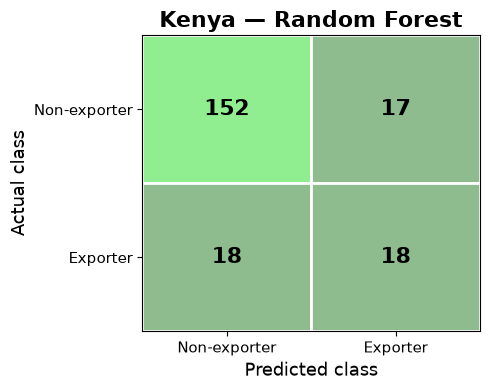

Tanzania — Preferred model: Random Forest


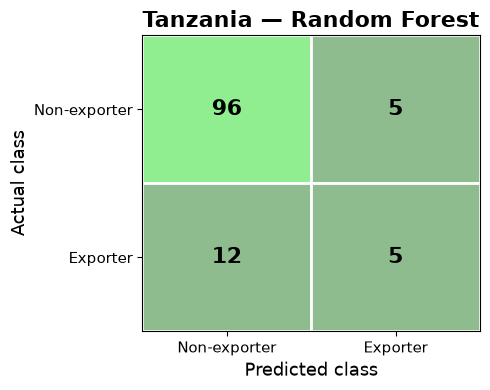

Uganda — Preferred model: Random Forest


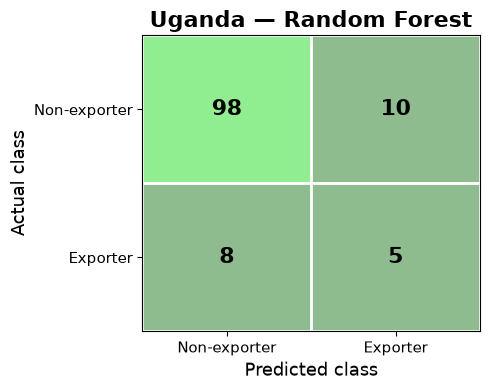

In [ ]:
# CELL 19 — CONFUSION MATRICES

# Create preferred model lookup
preferred_lookup = dict(
    zip(
        preferred_models["Country"],
        preferred_models["Model"]
    )
)

# Generate confusion matrices for preferred models
for country in countries:

    preferred_model = preferred_lookup[country]

    print(
        f"{country} — Preferred model: {preferred_model}"
    )

  

    if preferred_model == "BART-MIA":

        y_pred = bart_predictions[country]

    else:

        y_pred = predictions[country][preferred_model]

   

    y_true = y_test_eval[country]

   
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    )

   

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

   

    # Top row: Non-exporter actual class
    ax.add_patch(
        plt.Rectangle(
            (-0.5, -0.5),
            1,
            1,
            facecolor="lightgreen",
            edgecolor="white",
            linewidth=2
        )
    )

    ax.add_patch(
        plt.Rectangle(
            (0.5, -0.5),
            1,
            1,
            facecolor="darkseagreen",
            edgecolor="white",
            linewidth=2
        )
    )

    # Bottom row: Exporter actual class
    ax.add_patch(
        plt.Rectangle(
            (-0.5, 0.5),
            1,
            1,
            facecolor="darkseagreen",
            edgecolor="white",
            linewidth=2
        )
    )

    ax.add_patch(
        plt.Rectangle(
            (0.5, 0.5),
            1,
            1,
            facecolor="darkseagreen",
            edgecolor="white",
            linewidth=2
        )
    )

   

    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color="black"
            )

  

    ax.set_title(
        f"{country} — {preferred_model}",
        fontsize=16,
        fontweight="bold"
    )

 

    ax.set_xlabel(
        "Predicted class",
        fontsize=13
    )

    ax.set_ylabel(
        "Actual class",
        fontsize=13
    )

    

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(
        ["Non-exporter", "Exporter"],
        fontsize=11
    )

    ax.set_yticklabels(
        ["Non-exporter", "Exporter"],
        fontsize=11
    )

    # Keep the matrix boundaries correct
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

   

    plt.tight_layout()

    figure_path = (
        FIGURES_DIR /
        f"{country}_preferred_model_confusion_matrix.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

## 20. ROC Curves

Receiver Operating Characteristic (ROC) curves compare the discrimination
performance of the five models across classification thresholds.

The area under each ROC curve corresponds to the test-set ROC-AUC.

Separate figures are produced for Kenya, Tanzania, and Uganda to preserve
country-specific interpretation.

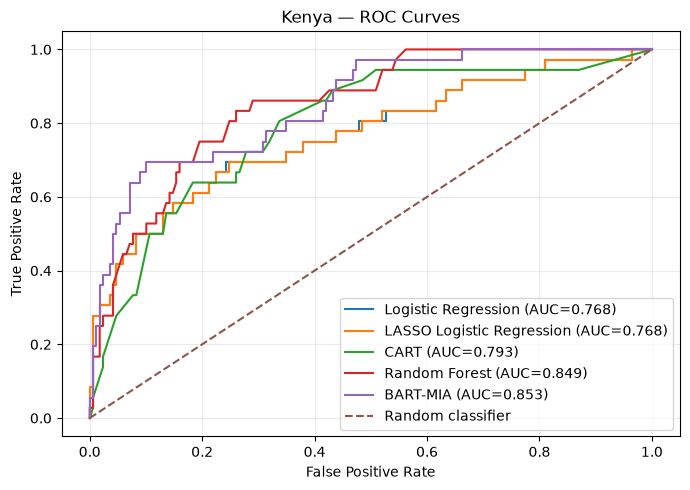

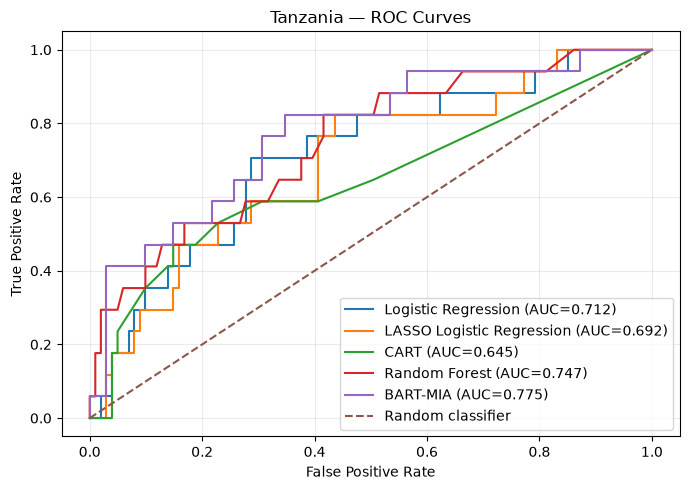

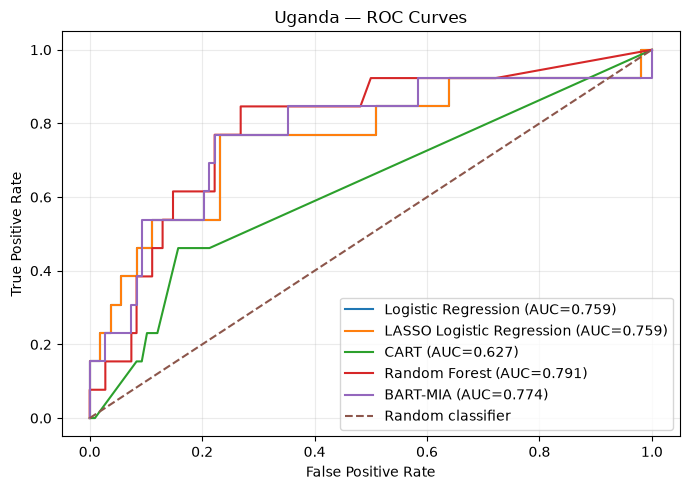

In [53]:

#  ROC CURVES


for country in countries:

    y_true = y_test_eval[country]

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

   
    # Traditional models
  

    for model_name in traditional_model_names:

        y_prob = probabilities[
            country
        ][model_name]

        fpr, tpr, _ = roc_curve(
            y_true,
            y_prob
        )

        auc_value = roc_auc_score(
            y_true,
            y_prob
        )

        ax.plot(
            fpr,
            tpr,
            label=(
                f"{model_name} "
                f"(AUC={auc_value:.3f})"
            )
        )

   
    # BART-MIA
   

    y_prob = bart_probabilities[country]

    fpr, tpr, _ = roc_curve(
        y_true,
        y_prob
    )

    auc_value = roc_auc_score(
        y_true,
        y_prob
    )

    ax.plot(
        fpr,
        tpr,
        label=(
            f"BART-MIA "
            f"(AUC={auc_value:.3f})"
        )
    )

    
    # Reference line
    

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random classifier"
    )

    ax.set_title(
        f"{country} — ROC Curves"
    )

    ax.set_xlabel(
        "False Positive Rate"
    )

    ax.set_ylabel(
        "True Positive Rate"
    )

    ax.legend(
        loc="lower right"
    )

    ax.grid(
        alpha=0.25
    )

    plt.tight_layout()

    figure_path = (
        FIGURES_DIR /
        f"{country}_ROC_curves.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 21. Precision–Recall Curves

Precision–Recall curves provide an additional assessment of model performance
when the positive class is relatively uncommon.

In this study, the positive class represents exporting firms.The curves show the trade-off between precision and recall across probability
thresholds.

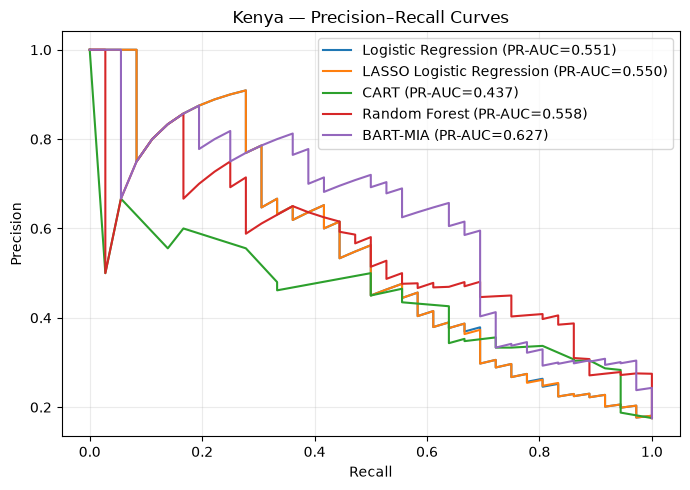

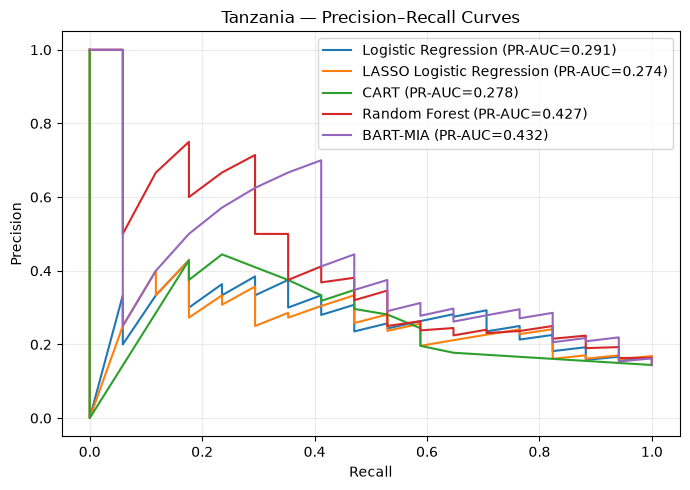

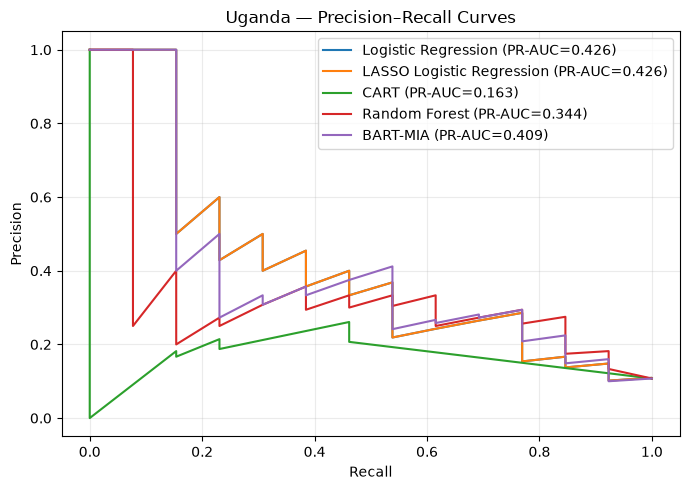

In [54]:

# PRECISION-RECALL CURVES


for country in countries:

    y_true = y_test_eval[country]

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    
    # Traditional models
   

    for model_name in traditional_model_names:

        y_prob = probabilities[
            country
        ][model_name]

        precision_curve, recall_curve, _ = (
            precision_recall_curve(
                y_true,
                y_prob
            )
        )

        pr_auc = average_precision_score(
            y_true,
            y_prob
        )

        ax.plot(
            recall_curve,
            precision_curve,
            label=(
                f"{model_name} "
                f"(PR-AUC={pr_auc:.3f})"
            )
        )

    # BART-MIA


    y_prob = bart_probabilities[country]

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true,
            y_prob
        )
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    ax.plot(
        recall_curve,
        precision_curve,
        label=(
            f"BART-MIA "
            f"(PR-AUC={pr_auc:.3f})"
        )
    )

    ax.set_title(
        f"{country} — Precision–Recall Curves"
    )

    ax.set_xlabel(
        "Recall"
    )

    ax.set_ylabel(
        "Precision"
    )

    ax.legend(
        loc="best"
    )

    ax.grid(
        alpha=0.25
    )

    plt.tight_layout()

    figure_path = (
       FIGURES_DIR /
        f"{country}_PR_curves.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 22. Test-Set ROC-AUC Comparison

A cross-country comparison of test-set ROC-AUC is presented to show how the
five modelling approaches perform on previously unseen firms.

This visual complements the numerical evaluation table and provides a concise
comparison of model discrimination across Kenya, Tanzania, and Uganda.

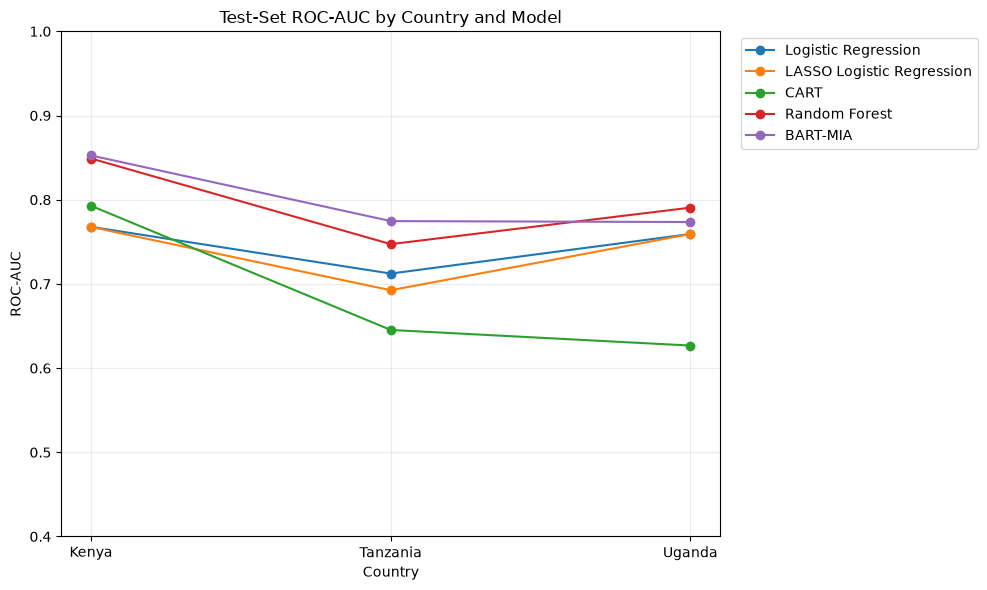

In [55]:

# CELL  ROC-AUC COMPARISON


plot_df = all_evaluation_results.copy()

fig, ax = plt.subplots(
    figsize=(10, 6)
)

for model_name in model_order:

    model_df = plot_df[
        plot_df["Model"] == model_name
    ]

    ax.plot(
        model_df["Country"],
        model_df["ROC_AUC"],
        marker="o",
        label=model_name
    )

ax.set_title(
    "Test-Set ROC-AUC by Country and Model"
)

ax.set_xlabel(
    "Country"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_ylim(
    0.4,
    1.0
)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

figure_path = (
    FIGURES_DIR /
    "test_ROC_AUC_model_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 23. Preferred Model — Final Test Performance

The preferred model identified during model development is now evaluated using
the untouched test observations.

This table represents the final country-specific predictive performance of the
models selected using cross-validated training performance.

Importantly, the test results are reported only after model selection has been
completed.

In [ ]:

# PREFERRED MODEL TEST PERFORMANCE


preferred_test_results = []

for _, row in preferred_models.iterrows():

    country = row["Country"]
    model_name = row["Model"]

    result = all_evaluation_results[
        (
            all_evaluation_results["Country"]
            == country
        )
        &
        (
            all_evaluation_results["Model"].astype(str)
            == model_name
        )
    ]

    if len(result) != 1:
        raise RuntimeError(
            f"Could not uniquely identify "
            f"{country} — {model_name}"
        )

    preferred_test_results.append(
        result.iloc[0]
    )

preferred_test_results_df = pd.DataFrame(
    preferred_test_results
)

preferred_test_results_df = (
    preferred_test_results_df[
        [
            "Country",
            "Model",
            "Accuracy",
            "Balanced_Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1",
            "ROC_AUC",
            "PR_AUC"
        ]
    ]
)

display(
    preferred_test_results_df.round(4)
)
assert len(

    preferred_test_results_df

) == len(countries)

assert set(

    preferred_test_results_df["Country"]

) == set(countries)

print(

    "\nPreferred-model test evaluation: PASSED"

)

,Country,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
3,Kenya,Random Forest,0.8293,0.6997,0.5143,0.5000,0.8994,0.5070,0.8489,0.5579
8,Tanzania,Random Forest,0.8559,0.6223,0.5000,0.2941,0.9505,0.3704,0.7472,0.4265
13,Uganda,Random Forest,0.8512,0.6460,0.3333,0.3846,0.9074,0.3571,0.7906,0.3437



Preferred-model test evaluation: PASSED


## 24. Cross-Validation versus Test-Set Performance

The cross-validation ROC-AUC obtained during model training is compared with the
ROC-AUC obtained on the untouched test set for the preferred model in each
country.

This comparison provides an indication of how well the selected models
generalise from the training data to previously unseen observations.

The difference between the two values is reported as the test-set ROC-AUC minus
the cross-validation ROC-AUC.

In [65]:

# CROSS-VALIDATION VS TEST PERFORMANCE


# Prepare training-stage results

training_preferred = preferred_models[
    [
        "Country",
        "Model",
        "Best_CV_ROC_AUC"
    ]
].copy()

training_preferred = training_preferred.rename(
    columns={
        "Best_CV_ROC_AUC": "CV_ROC_AUC"
    }
)


# Prepare test-stage results

test_preferred = preferred_test_results_df[
    [
        "Country",
        "Model",
        "ROC_AUC"
    ]
].copy()

test_preferred = test_preferred.rename(
    columns={
        "ROC_AUC": "Test_ROC_AUC"
    }
)


# Merge

generalisation_results = training_preferred.merge(
    test_preferred,
    on=[
        "Country",
        "Model"
    ],
    how="inner"
)


# Calculate difference

generalisation_results[
    "Test_minus_CV"
] = (
    generalisation_results["Test_ROC_AUC"]
    -
    generalisation_results["CV_ROC_AUC"]
)


# Display

display(
    generalisation_results.round(4)
)


# Validation

assert len(
    generalisation_results
) == len(countries)

print(
    "\nCross-validation versus test-set comparison: PASSED"
)

,Country,Model,CV_ROC_AUC,Test_ROC_AUC,Test_minus_CV
0,Kenya,Random Forest,0.9574,0.8489,-0.1085
1,Tanzania,Random Forest,0.9733,0.7472,-0.2261
2,Uganda,Random Forest,0.9905,0.7906,-0.1999



Cross-validation versus test-set comparison: PASSED


## 25. Save Final Evaluation Results

The final out-of-sample evaluation tables are saved for subsequent thesis
reporting and interpretation.

The complete five-model results, preferred-model results, and
cross-validation-versus-test comparison are stored separately.

In [66]:
# SAVE FINAL EVALUATION RESULTS


# Ensure directories exist


EVALUATION_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)



# Save complete five-model evaluation


all_results_path = (
    EVALUATION_RESULTS_DIR /
    "all_five_model_test_results.csv"
)

all_evaluation_results.to_csv(
    all_results_path,
    index=False
)



# Save preferred-model results


preferred_results_path = (
    EVALUATION_RESULTS_DIR /
    "preferred_model_test_results.csv"
)

preferred_test_results_df.to_csv(
    preferred_results_path,
    index=False
)



# Save CV versus test results


generalisation_path = (
    EVALUATION_RESULTS_DIR /
    "preferred_model_cv_vs_test_results.csv"
)

generalisation_results.to_csv(
    generalisation_path,
    index=False
)



# Print saved files


print("Evaluation results saved:")
print(
    f"  {all_results_path}"
)

print(
    f"  {preferred_results_path}"
)

print(
    f"  {generalisation_path}"
)

print(
    f"\nFigures directory:"
)

print(
    FIGURES_DIR
)

Evaluation results saved:
  /Users/eddiebest/Documents/SME_Export_Thesis/results/evaluation/all_five_model_test_results.csv
  /Users/eddiebest/Documents/SME_Export_Thesis/results/evaluation/preferred_model_test_results.csv
  /Users/eddiebest/Documents/SME_Export_Thesis/results/evaluation/preferred_model_cv_vs_test_results.csv

Figures directory:
results/figures


In [67]:
# FINAL EVALUATION VALIDATION
expected_models = {
    "Logistic Regression",
    "LASSO Logistic Regression",
    "CART",
    "Random Forest",
    "BART-MIA"
}

expected_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]



# 1. Total evaluations


assert len(
    all_evaluation_results
) == 15

print(
    "Total model-country evaluations: 15 — PASSED"
)


# 2. Country coverage
assert set(
    all_evaluation_results["Country"].unique()
) == set(countries)

print(
    "Country coverage — PASSED"
)


# 3. Model coverage
assert set(
    all_evaluation_results["Model"].astype(str)
) == expected_models

print(
    "Five-model coverage — PASSED"
)


# 4. Five models per country
model_counts = (
    all_evaluation_results
    .groupby(
        "Country",
        observed=False
    )["Model"]
    .nunique()
)

assert (
    model_counts == 5
).all()

print(
    "Five models per country — PASSED"
)


# 5. Required metrics
for metric in expected_metrics:

    assert metric in (
        all_evaluation_results.columns
    )

    assert (
        all_evaluation_results[metric]
        .notna()
        .all()
    )

print(
    "All evaluation metrics — PASSED"
)


# 6. BART-MIA coverage
bart_count = (
    all_evaluation_results["Model"]
    .astype(str)
    .eq("BART-MIA")
    .sum()
)

assert bart_count == 3

print(
    "BART-MIA evaluation coverage — PASSED"
)


# 7. Preferred models
assert len(
    preferred_test_results_df
) == 3

assert set(
    preferred_test_results_df["Country"]
) == set(countries)

print(
    "Preferred-model evaluation — PASSED"
)

# 8. Generalisation comparison
assert len(
    generalisation_results
) == 3

print(
    "CV versus test comparison — PASSED"
)



# FINAL SUMMARY




print(
    "\nCountries evaluated: 3"
)

print(
    "Models evaluated per country: 5"
)

print(
    "Total model-country evaluations: 15"
)

print(
    "BART-MIA evaluations: 3"
)

print(
    "\nPreferred models:"
)

display(
    preferred_test_results_df.round(4)
)

print(
    "\nAll final evaluation tables and figures have been saved."
)

Total model-country evaluations: 15 — PASSED
Country coverage — PASSED
Five-model coverage — PASSED
Five models per country — PASSED
All evaluation metrics — PASSED
BART-MIA evaluation coverage — PASSED
Preferred-model evaluation — PASSED
CV versus test comparison — PASSED

Countries evaluated: 3
Models evaluated per country: 5
Total model-country evaluations: 15
BART-MIA evaluations: 3

Preferred models:


,Country,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,Kenya,Random Forest,0.8293,0.6997,0.5143,0.5000,0.8994,0.5070,0.8489,0.5579
1,Tanzania,Random Forest,0.8559,0.6223,0.5000,0.2941,0.9505,0.3704,0.7472,0.4265
2,Uganda,Random Forest,0.8512,0.6460,0.3333,0.3846,0.9074,0.3571,0.7906,0.3437



All final evaluation tables and figures have been saved.


In [ ]:
display(
    all_evaluation_results.round(4)
)

,Country,Model,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,PR_AUC
0,Kenya,Logistic Regression,0.7659,0.7050,0.3929,0.6111,0.7988,0.4783,0.7678,0.5505
1,Kenya,LASSO Logistic Regression,0.7659,0.7050,0.3929,0.6111,0.7988,0.4783,0.7676,0.5503
2,Kenya,CART,0.7951,0.7009,0.4348,0.5556,0.8462,0.4878,0.7927,0.4371
3,Kenya,Random Forest,0.8293,0.6997,0.5143,0.5000,0.8994,0.5070,0.8489,0.5579
4,Kenya,BART-MIA,0.8634,0.6439,0.7857,0.3056,0.9822,0.4400,0.8526,0.6266
5,Tanzania,Logistic Regression,0.7119,0.6360,0.2571,0.5294,0.7426,0.3462,0.7123,0.2914
6,Tanzania,LASSO Logistic Regression,0.6695,0.6357,0.2381,0.5882,0.6832,0.3390,0.6925,0.2741
7,Tanzania,CART,0.7881,0.6316,0.3182,0.4118,0.8515,0.3590,0.6453,0.2781
8,Tanzania,Random Forest,0.8559,0.6223,0.5000,0.2941,0.9505,0.3704,0.7472,0.4265
9,Tanzania,BART-MIA,0.8475,0.5195,0.3333,0.0588,0.9802,0.1000,0.7746,0.4324
